In [11]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from pathlib import Path
import xcdat as xc
import cmasher as cmr
import xarray as xr
import sys

sys.path.append('../../functions/')
from lag_linregress import *
from monthly_departures import *
from MCA import *

# Reload edited Python modules automatically before running subsequent cells.
%load_ext autoreload
%autoreload 2

import sys

# Add the project folder only once, even if this cell is rerun.
functions_path = "/scratch/leiff/MCA/amip_clean/project_functions/"
if functions_path not in sys.path:
    sys.path.append(functions_path)

from MCA_cov import *
from significance import *
from plotting import *
from diagnostics import *
# from taylor_setup import *
from setup_diagnostic import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
# Little janky but this block gives us important common info
filepath_output_era5    = '/scratch/leiff/MCA/amip_clean/data/ERA5/tas_194001-202412_g025.nc'
ERA5                    = xc.open_dataset(filepath_output_era5).sel(time=slice('2000-03','2014-12')).rename_vars({
                            "t2m": "tas",})
ERA5['weights']         = ERA5['tas'][0]*0 + np.cos(np.deg2rad(ERA5.lat))
lat = ERA5.lat
lon = ERA5.lon
reference_grid = ERA5['tas'].isel(time=0).load()

raw_weights     = np.cos(np.deg2rad(lat.values))[:, None] * np.ones(reference_grid.shape)
raw_weights     = np.where(np.isfinite(reference_grid.values), raw_weights, 0.)
global_weights  = raw_weights / raw_weights.sum()

In [13]:
# %% 1. Settings: the member-specific SEP index, source paths, and output choices
import numpy as np
import xarray as xr
from pathlib import Path

sep_core_dir = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412")
sep_stationarity_dir = sep_core_dir / "stationarity"
sep_raw_dir = Path("/scratch/leiff/MCA/amip_clean/data/AMIP")
sep_regional_path = sep_stationarity_dir / "regional/march_n178_regional.npy"
sep_savepath = sep_stationarity_dir / "SEP_relationships/amip_SEP_window_relationships_hist.npy"
# Choose all historical models, or only those matched to AMIP.
sep_experiment, sep_region, sep_index_key = "historical", "SEP", "cov_Zi_R"
# sep_experiment = "historical_matched"
sep_min_windows = 3

# Both historical groups use the same underlying coupled files.
sep_raw_experiment = "historical"
sep_raw_dir = Path("/scratch/leiff/MCA/amip_clean/data/HIST")
sep_savepath = sep_stationarity_dir / f"SEP_relationships/{sep_experiment}_SEP_window_relationships.npy"

# "index": correlate each local SD with that member's SEP covariance index.
# "local_local": correlate local sigma_Ti with local sigma_Ri across windows.
# "both": keep both questions. No temporal SDs are recalculated or detrended here.
sep_sd_relationship = "index"
sep_confirmed_member_ids = None  # Optional {model: IDs in SAVED stationarity member order}.
sep_save, sep_overwrite = True, False  # Saving happens only in the separate save cell.
sep_calculated, sep_aggregated = False, False




In [14]:
# %% 2. Small numerical helpers: all operations retain the start-year interpretation
def sep_finite_mean(values):
    """Arithmetic finite mean over axis 0, with contributor counts."""
    values = np.asarray(values, dtype=float)
    valid = np.isfinite(values)
    total, count = np.where(valid, values, 0.).sum(axis=0), valid.sum(axis=0)
    return np.divide(total, count, out=np.full_like(total, np.nan), where=count > 0), count


def sep_area_mean(fields, weights):
    """Reduce final lat/lon axes; also return fraction of requested area retained."""
    support = np.isfinite(weights) & (weights > 0)
    if not support.any():
        raise ValueError("No positive area weights.")
    w = weights[support] / weights[support].max()
    values = np.asarray(fields[..., support], dtype=float)
    valid = np.isfinite(values)
    numerator = np.sum(np.where(valid, values, 0.)*w, axis=-1)
    denominator = np.sum(valid*w, axis=-1)
    return np.divide(numerator, denominator, out=np.full_like(numerator, np.nan), where=denominator > 0), denominator/w.sum()


def sep_window_fit(x, y, min_windows=3):
    """Fit y = intercept + slope*x over WINDOW START YEARS; return slope, r, n.

    y is (start_year, lat, lon); x can be a matching field or a 1-D index.
    Equal window weights, paired finite values, intercept included. No p-values:
    neighboring 178-month windows overlap strongly. This is not a monthly fit.
    """
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    if y.ndim != 3 or min_windows < 2:
        raise ValueError("Expected a window/lat/lon response and min_windows >= 2.")
    if x.ndim == 1:
        x = x[:, None, None]
    x = np.broadcast_to(x, y.shape)
    valid = np.isfinite(x) & np.isfinite(y)
    n = valid.sum(axis=0)
    mx = np.divide(np.where(valid, x, 0.).sum(axis=0), n, out=np.zeros(y.shape[1:]), where=n > 0)
    my = np.divide(np.where(valid, y, 0.).sum(axis=0), n, out=np.zeros(y.shape[1:]), where=n > 0)
    dx, dy = np.where(valid, x, mx) - mx, np.where(valid, y, my) - my
    xx, yy, xy = np.sum(dx*dx, axis=0), np.sum(dy*dy, axis=0), np.sum(dx*dy, axis=0)
    # Explicit ranges detect constant decimal-valued inputs even when floating-
    # point averaging leaves a tiny nonzero sum of squared deviations.
    varying_x = np.max(np.where(valid, x, -np.inf), axis=0) > np.min(np.where(valid, x, np.inf), axis=0)
    varying_y = np.max(np.where(valid, y, -np.inf), axis=0) > np.min(np.where(valid, y, np.inf), axis=0)
    xy = np.where(varying_y, xy, 0.)
    slope = np.divide(xy, xx, out=np.full_like(xx, np.nan), where=(n >= min_windows) & varying_x & (xx > 0))
    denominator = np.sqrt(xx)*np.sqrt(yy)
    corr = np.divide(xy, denominator, out=np.full_like(xx, np.nan),
                     where=(n >= min_windows) & varying_x & varying_y & (xx > 0) & (yy > 0))
    return slope, np.clip(corr, -1., 1.), n


def sep_raw_window_means(values, starts, length):
    """Equal-month means of RAW (time,lat,lon) data; require all months per cell."""
    values = np.asarray(values, dtype=float)
    starts = np.asarray(starts, dtype=int)
    if values.ndim != 3 or np.any(starts < 0) or np.any(starts + length > len(values)):
        raise ValueError("Raw field/window bounds do not agree.")
    # Cumulative sums avoid rereading/reaveraging the same 166 overlapping months.
    # Counts prevent a missing month from silently changing the period definition.
    finite = np.isfinite(values)
    sums = np.zeros((len(values) + 1,) + values.shape[1:])
    counts = np.zeros(sums.shape, dtype=np.int32)
    np.cumsum(np.where(finite, values, 0.), axis=0, out=sums[1:])
    np.cumsum(finite, axis=0, dtype=np.int32, out=counts[1:])
    total = sums[starts + length] - sums[starts]
    complete = counts[starts + length] - counts[starts] == length
    return np.where(complete, total/length, np.nan)


def sep_prepare_raw(field, months, lat, lon):
    """Check months/grid and expose one possible member axis without loading data."""
    field = field.sel(time=slice(str(months[0]), str(months[-1])))
    actual = np.asarray(field.time.dt.year*12 + field.time.dt.month - 1)
    if not np.array_equal(actual, months.astype(int) + 1970*12):
        raise ValueError(f"{field.name}: missing, repeated, or reordered months.")
    for dim, expected in [("lat", lat), ("lon", lon)]:
        coordinate = np.asarray(field[dim])
        if coordinate.shape != expected.shape or not np.allclose(coordinate, expected, rtol=0, atol=1e-6):
            raise ValueError(f"{field.name}: {dim} must match the stationarity grid/order.")
    extra = [d for d in field.dims if d not in ["time", "lat", "lon"]]
    if len(extra) > 1:
        raise ValueError(f"Select extra dimensions first: {field.dims}")
    if extra:
        dim = extra[0]
        ids = np.asarray(field[dim]).astype(str) if dim in field.coords else np.arange(field.sizes[dim]).astype(str)
        field = field.rename({dim: "member"}) if dim != "member" else field
        field = field.assign_coords(member=ids)
    else:
        field = field.expand_dims(member=["single"])
    if len(set(field.member.values.tolist())) != field.sizes["member"]:
        raise ValueError("Duplicate raw member IDs.")
    return field.transpose("member", "time", "lat", "lon")




In [15]:
# %% 3. Load the small regional/observation files and register the output quantities
sep_regional = np.load(sep_regional_path, allow_pickle=True).item()
sep_observations = np.load(sep_core_dir / "overlap_observations.npy", allow_pickle=True).item()
sep_meta = sep_regional["metadata"]
sep_years = np.asarray(sep_meta["start_years"])
sep_start_months = np.asarray(sep_meta["start_months"], dtype="datetime64[M]")
sep_end_months = np.asarray(sep_meta["end_months"], dtype="datetime64[M]")
sep_window_months = int(sep_meta["window_months"])
if (sep_window_months != 178 or not np.array_equal(sep_start_months.astype(int) % 12, np.full(len(sep_years), 2))
        or not np.array_equal(sep_end_months, sep_start_months + np.timedelta64(177, "M"))
        or not np.array_equal(sep_start_months.astype("datetime64[Y]").astype(int) + 1970, sep_years)
        or np.any(np.diff(sep_years) != 1)):
    raise ValueError("Expected consecutive March-start, 178-month windows and matching year labels.")
sep_months = np.arange(sep_start_months[0], sep_end_months[-1] + np.timedelta64(1, "M"))
sep_window_starts = (sep_start_months - sep_months[0]).astype(int)
sep_lat, sep_lon = [np.asarray(sep_meta[k], dtype=float) for k in ["lat", "lon"]]
sep_shape = (len(sep_lat), len(sep_lon))
sep_weights = np.array(sep_meta["weights"], dtype=float, copy=True)
if sep_weights.shape != sep_shape or np.any(np.isfinite(sep_weights) & (sep_weights < 0)):
    raise ValueError("Expected nonnegative lat/lon area weights.")
sep_weights = np.where(np.isfinite(sep_weights) & (sep_weights > 0), sep_weights, 0.)
if sep_weights.sum() <= 0:
    raise ValueError("No positive area weights.")
sep_weights /= sep_weights.sum()
sep_mask = np.asarray(sep_regional["regions"][sep_region], dtype=bool)
if sep_mask.shape != sep_shape or not np.any(sep_mask & (sep_weights > 0)):
    raise ValueError("SEP mask must contain positive-weight cells on the full grid.")
sep_region_weights = np.where(sep_mask, sep_weights, 0.)
sep_models = list(sep_meta["model_names"][sep_experiment])
if not sep_models or len(set(sep_models)) != len(sep_models):
    raise ValueError("Expected a nonempty list of unique AMIP models.")
if sep_sd_relationship not in ["index", "local_local", "both"]:
    raise ValueError("Choose index, local_local, or both for sep_sd_relationship.")

# The plotted index is cov_Zi_R, NOT raw cov_Ti_R. Each member gets its OWN index.
# Means of fitted maps below are means of member diagnostics, never fits of MMMs.
sep_quantity_info = {"SEP_index": {"kind": "series", "units": "W m-2", "meaning": "Member-specific SEP cov_Zi_R index"}}
if sep_sd_relationship in ["index", "both"]:
    for field in ["sigma_Ti", "sigma_Ri"]:
        sep_quantity_info[f"corr_{field}_SEP"] = {"kind": "map", "units": "1", "meaning": f"Local {field} correlated with SEP index across windows"}
if sep_sd_relationship in ["local_local", "both"]:
    sep_quantity_info["corr_sigma_Ti_sigma_Ri"] = {"kind": "map", "units": "1", "meaning": "Local SDs correlated with each other across windows"}
for field, units in [("mean_Ti", "K / (W m-2)"), ("mean_Ni", "1")]:
    sep_quantity_info[f"slope_{field}_SEP"] = {"kind": "map", "units": units, "meaning": f"Raw local {field} regressed ON SEP index across windows"}
    sep_quantity_info[f"corr_{field}_SEP"] = {"kind": "map", "units": "1", "meaning": f"Raw local {field} correlated with SEP index across windows"}
for field in ["Ti", "Ri"]:
    for reduction in ["mean", "abs_mean"]:
        sep_quantity_info[f"global_logvar_{field}_{reduction}"] = {"kind": "series", "units": "1", "meaning": f"Area {reduction} of local {field} log variance ratio versus fixed observations"}

# YOUR NEW METRIC: register a map/series key above, assign it in 'here' below;
# storage and member -> model -> MMM aggregation then handle it automatically.
sep_obs_log_sd = {}
for field in ["Ti", "Ri"]:
    sd = np.asarray(sep_observations[f"sigma_{field}"], dtype=float)
    if sd.shape != sep_shape or np.any(sd[np.isfinite(sd)] < 0):
        raise ValueError(f"Observed sigma_{field}: invalid SD map.")
    sep_obs_log_sd[field] = np.log(sd, out=np.full_like(sd, np.nan), where=np.isfinite(sd) & (sd > 0))




In [16]:
# %% 4. Main calculation: one model dictionary, then one raw member, at a time
sep_calculated, sep_aggregated = False, False
sep_member_values = {sep_experiment: {q: {} for q in sep_quantity_info}}
sep_fit_n_windows, sep_logvar_coverage, sep_member_ids, sep_sources = {}, {}, {}, {}
for model in sep_models:
    print(f"{sep_experiment} / {model}", flush=True)
    path = sep_stationarity_dir / f"march_n178_{sep_experiment}_{model}_member_values.npy"
    source = np.load(path, allow_pickle=True).item()  # Pickle format loads ALL quantities for this model.
    index = np.asarray(sep_regional["member_values"][sep_experiment][sep_index_key][sep_region][model], dtype=float)
    n_members = index.shape[0]
    if index.ndim != 2 or n_members < 1 or index.shape[1] != len(sep_years):
        raise ValueError(f"{model}: regional index must be (member, start_year).")
    for key in [sep_index_key, "sigma_Ti", "sigma_Ri"]:
        if np.shape(source[key]) != (n_members, len(sep_years)) + sep_shape:
            raise ValueError(f"{model}/{key}: expected matching (member, year, lat, lon).")

    # Confirm the cached regional series comes from THESE maps in this member
    # order. This catches a stale regional bundle or a changed stationarity file.
    check_index, _ = sep_area_mean(source[sep_index_key], sep_region_weights)
    if not np.allclose(index, check_index, rtol=1e-10, atol=1e-12, equal_nan=True):
        raise ValueError(f"{model}: cached SEP index differs from source maps; rebuild/check alignment.")
    collected = {q: [] for q in sep_quantity_info}
    fit_counts, coverage = {}, {field: [] for field in ["Ti", "Ri"]}
    paths = {}
    for var in ["tas", "N"]:
        candidates = sorted((sep_raw_dir / model).glob(f"{var}_Amon_{model}_*{sep_raw_experiment}*combined*187001-201412_g025.nc"))
        if len(candidates) != 1:
            raise ValueError(f"{model}/{var}: expected exactly one combined raw file, found {candidates}.")
        paths[var] = candidates[0]
    sep_sources[model] = {key: {"path": str(p), "size_bytes": p.stat().st_size, "mtime_ns": p.stat().st_mtime_ns}
                          for key, p in {"stationarity": path, **paths}.items()}

    # Open each raw file once. All loading happens inside the file contexts;
    # processed outputs are NumPy arrays that no longer depend on open datasets.
    with xr.open_dataset(paths["tas"]) as ds_T, xr.open_dataset(paths["N"]) as ds_N:
        fields = {"mean_Ti": sep_prepare_raw(ds_T["tas"], sep_months, sep_lat, sep_lon),
                  "mean_Ni": sep_prepare_raw(ds_N["N"], sep_months, sep_lat, sep_lon)}
        # If the stationarity archive has confirmed labels, use them. Otherwise
        # retain the original file positions, as in your stationarity-generation
        # loop, and check T/N member IDs/order. Plain .npy arrays cannot prove IDs.
        ids = None if sep_confirmed_member_ids is None else np.asarray(sep_confirmed_member_ids[model]).astype(str)
        if ids is None and sep_meta.get("member_label_kind") == "user-confirmed member IDs":
            ids = np.asarray(sep_meta["member_labels"][sep_experiment][model]).astype(str)
        if ids is not None:
            if len(ids) != n_members or len(set(ids)) != n_members:
                raise ValueError(f"{model}: invalid confirmed member IDs.")
            fields = {key: field.sel(member=ids) for key, field in fields.items()}
        if any(field.sizes["member"] != n_members for field in fields.values()):
            raise ValueError(f"{model}: raw/stationarity member counts differ.")
        if not np.array_equal(fields["mean_Ti"].member.values, fields["mean_Ni"].member.values):
            raise ValueError(f"{model}: raw T/N member orders differ; supply confirmed stationarity IDs.")
        sep_member_ids[model] = {"raw_ids": fields["mean_Ti"].member.values.copy(),
                                 "alignment": "confirmed IDs" if ids is not None else "assumed original file positions"}
        sep_sources[model]["raw_units"] = {key: field.attrs.get("units", "not supplied") for key, field in fields.items()}
        # Slopes retain the raw physical units. Refuse a contradictory unit label;
        # missing labels retain the stated CMIP tas=K / N=W m-2 assumption explicitly.
        allowed_units = {"mean_Ti": {"K", "kelvin", "Kelvin"},
                         "mean_Ni": {"W m-2", "W m^-2", "W m**-2", "W/m2", "W m−2"}}
        for key, units in sep_sources[model]["raw_units"].items():
            if units != "not supplied" and units not in allowed_units[key]:
                raise ValueError(f"{model}/{key}: convert units {units!r} explicitly before comparing models.")

        for member in range(n_members):
            here, x = {"SEP_index": index[member].copy()}, index[member]
            sTi, sRi = [np.asarray(source[key][member], dtype=float) for key in ["sigma_Ti", "sigma_Ri"]]
            for field, sd in [("Ti", sTi), ("Ri", sRi)]:
                if np.any(sd[np.isfinite(sd)] < 0):
                    raise ValueError(f"{model}/{member}: negative SD.")
                if sep_sd_relationship in ["index", "both"]:
                    _, here[f"corr_sigma_{field}_SEP"], n = sep_window_fit(x, sd, sep_min_windows)
                    fit_counts.setdefault(f"sigma_{field}_SEP", []).append(n)

                # Fixed OBS reference for every historical window. Natural logs
                # of LOCAL variances, then area means: not variance of global T/R.
                # Signed mean = log of geometric mean ratio; +/- errors can cancel.
                # Mean absolute log ratio is the non-cancelling companion score.
                log_sd = np.log(sd, out=np.full_like(sd, np.nan), where=np.isfinite(sd) & (sd > 0))
                log_ratio = 2*(log_sd - sep_obs_log_sd[field])
                here[f"global_logvar_{field}_mean"], valid_area = sep_area_mean(log_ratio, sep_weights)
                here[f"global_logvar_{field}_abs_mean"], _ = sep_area_mean(np.abs(log_ratio), sep_weights)
                coverage[field].append(valid_area)
            if sep_sd_relationship in ["local_local", "both"]:
                _, here["corr_sigma_Ti_sigma_Ri"], n = sep_window_fit(sTi, sRi, sep_min_windows)
                fit_counts.setdefault("sigma_Ti_sigma_Ri", []).append(n)

            # Raw monthly mean states: trends and climatology are RETAINED. Give
            # each monthly mean equal weight; no day-count/calendar weighting.
            # Process T and N sequentially to avoid holding both monthly arrays.
            for field, data in fields.items():
                raw = np.asarray(data.isel(member=member).values, dtype=float)
                window_means = sep_raw_window_means(raw, sep_window_starts, sep_window_months)
                del raw
                slope, corr, n = sep_window_fit(x, window_means, sep_min_windows)
                here[f"slope_{field}_SEP"], here[f"corr_{field}_SEP"] = slope, corr
                fit_counts.setdefault(f"{field}_SEP", []).append(n)
                del window_means

            # YOUR NEW METRIC: calculate here["your_key"] here, before storage.
            if set(here) != set(sep_quantity_info):
                raise ValueError("Calculated keys differ from the quantity registry.")
            for key, value in here.items():
                collected[key].append(value)
    for key, values in collected.items():
        sep_member_values[sep_experiment][key][model] = np.stack(values)
    sep_fit_n_windows[model] = {key: np.stack(values) for key, values in fit_counts.items()}
    sep_logvar_coverage[model] = {key: np.stack(values) for key, values in coverage.items()}
    del source, sTi, sRi, sd, log_sd, log_ratio
sep_calculated = True




historical / ACCESS-CM2


In [8]:
# %% 5. Aggregate MEMBER DIAGNOSTICS within model, then give every model one vote
if not sep_calculated:
    raise RuntimeError("Complete the member calculations before aggregating.")
sep_model_means, sep_MMM, sep_model_n_valid, sep_MMM_n_valid = [{sep_experiment: {}} for _ in range(4)]
for key in sep_quantity_info:
    means, counts = zip(*(sep_finite_mean(sep_member_values[sep_experiment][key][model]) for model in sep_models))
    sep_model_means[sep_experiment][key] = np.stack(means)
    sep_model_n_valid[sep_experiment][key] = np.stack(counts)
    sep_MMM[sep_experiment][key], sep_MMM_n_valid[sep_experiment][key] = sep_finite_mean(np.stack(means))

sep_archive = {
    "schema": "amip_sep_window_relationships", "member_values": sep_member_values,
    "model_means": sep_model_means, "MMM": sep_MMM,
    "model_n_valid": sep_model_n_valid, "MMM_n_valid": sep_MMM_n_valid,
    "fit_n_windows": {sep_experiment: sep_fit_n_windows},
    "logvar_valid_area_fraction": {sep_experiment: sep_logvar_coverage},
    "quantity_info": sep_quantity_info, "model_names": {sep_experiment: sep_models},
    "member_alignment": {sep_experiment: sep_member_ids},
    "coordinates": {"lat": sep_lat, "lon": sep_lon, "start_year": sep_years,
                    "start_month": sep_start_months, "end_month": sep_end_months, "area_weights": sep_weights},
    "metadata": {"index_quantity": sep_index_key, "index_region": sep_region, "regional_path": str(sep_regional_path),
                 "region_mask": sep_mask, "window_months": sep_window_months, "min_fit_windows": sep_min_windows,
                 "sd_relationship": sep_sd_relationship, "sources": sep_sources,
                 "obs_reference_period": sep_meta["observation_period"], "obs_source": str(sep_core_dir / "overlap_observations.npy"),
                 "raw_mean": "Equal-month raw mean; all 178 months required per cell; no deseasonalizing/detrending",
                 "regression": "Local response on member-specific raw SEP index, with intercept, equal weights across paired finite windows",
                 "aggregation": "Arithmetic means of member diagnostic maps/series per model, then equal-model means; no Fisher-z",
                 "logvar": "Area mean of ln(member local variance / fixed observed local variance), and mean absolute log ratio",
                 "missingness": "Fits: paired finite windows; log means: positive finite SDs and valid area, renormalized each window",
                 "cautions": "Overlapping windows and common trends preclude ordinary independent-window p-values or causal interpretation"},
    "observed_sigma": {key: np.asarray(sep_observations[f"sigma_{key}"]) for key in ["Ti", "Ri"]},
}
sep_aggregated = True
print("Ready: member maps/series, model means, and AMIP MMM; no files saved yet.")
# Examples to inspect before saving:
# sep_member_values["amip_hist"]["corr_sigma_Ti_SEP"][sep_models[0]][0]
# sep_model_means["amip_hist"]["slope_mean_Ti_SEP"][0]
# sep_MMM["amip_hist"]["global_logvar_Ti_abs_mean"]




Ready: member maps/series, model means, and AMIP MMM; no files saved yet.


In [9]:
# %% 6. Save: a separate, self-contained result bundle; never replace inputs
import os
import tempfile

if sep_save:
    if not (sep_calculated and sep_aggregated):
        raise RuntimeError("Finish calculation and aggregation first.")
    sep_savepath.parent.mkdir(parents=True, exist_ok=True)
    if sep_savepath.exists() and not sep_overwrite:
        raise FileExistsError(f"{sep_savepath} exists; choose another name or set sep_overwrite=True.")
    fd, temporary = tempfile.mkstemp(prefix=".sep_", suffix=".tmp", dir=sep_savepath.parent)
    try:
        with os.fdopen(fd, "wb") as handle:
            np.save(handle, sep_archive, allow_pickle=True)
        if sep_overwrite:
            os.replace(temporary, sep_savepath)
        else:
            os.link(temporary, sep_savepath)
    finally:
        if os.path.exists(temporary):
            os.unlink(temporary)
    print(f"Saved: {sep_savepath}")




Saved: /scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/stationarity/SEP_relationships/amip_SEP_window_relationships.npy


In [10]:
# %% 7. Load-only option: uses separate names and does not overwrite new results
import numpy as np
from pathlib import Path

load_sep_results = False
if load_sep_results:
    # path = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/stationarity/SEP_relationships/amip_SEP_window_relationships.npy")
    path = sep_savepath
    loaded_sep_archive = np.load(path, allow_pickle=True).item()
    if loaded_sep_archive.get("schema") != "amip_sep_window_relationships":
        raise ValueError("Unexpected bundle type.")




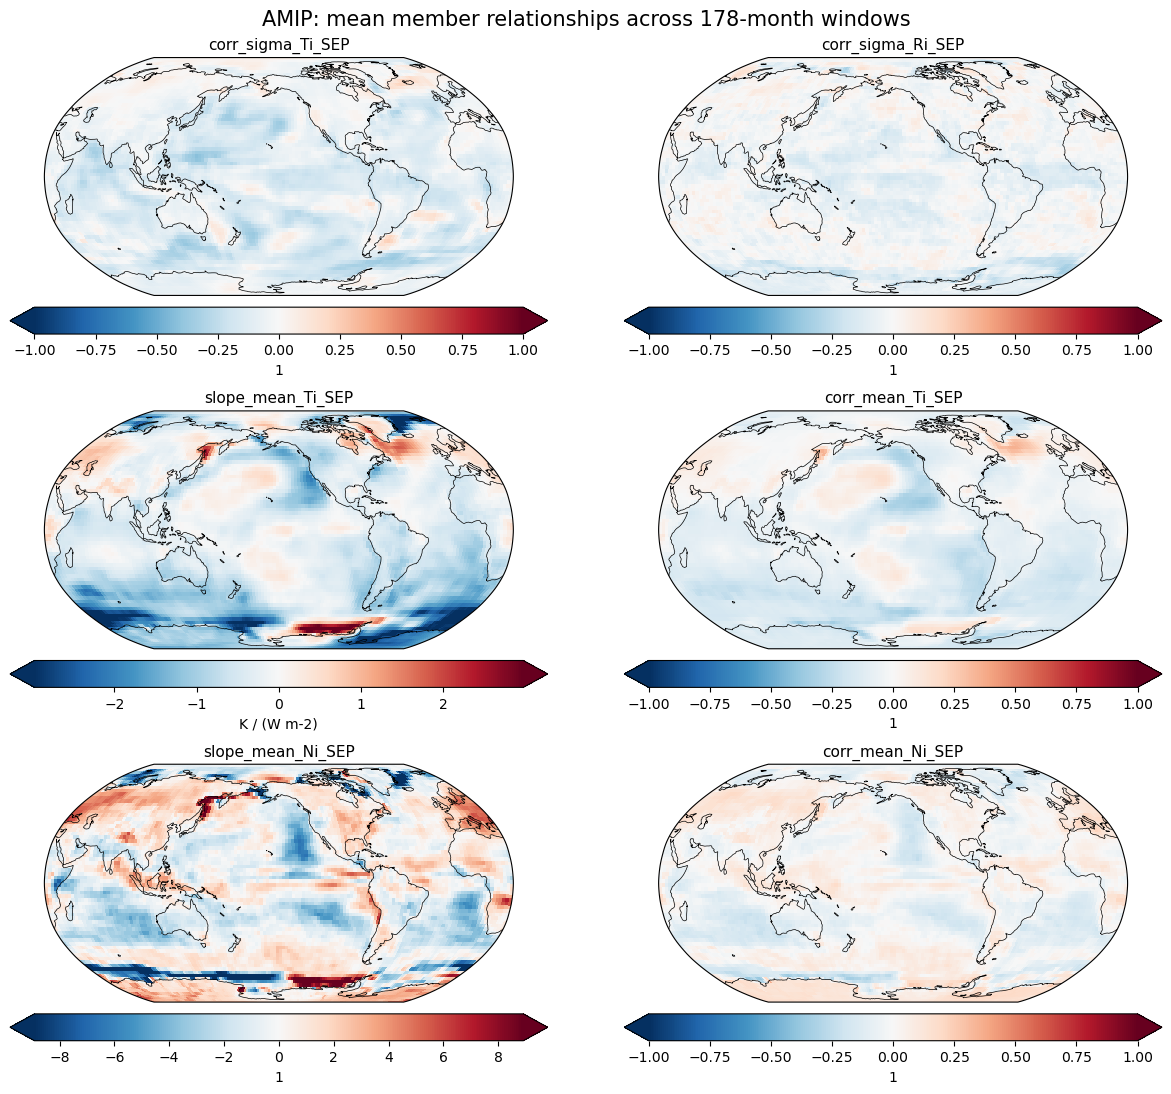

In [11]:
# %% 8. Quick MMM maps: correlations [-1,1]; each slope gets its own physical scale
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

sep_plot_archive = sep_archive  # Or loaded_sep_archive after running the load cell.
# Each saved bundle contains one experiment; read its actual key.
experiment = next(iter(sep_plot_archive["MMM"]))
lat, lon = [sep_plot_archive["coordinates"][k] for k in ["lat", "lon"]]
map_keys = [q for q, info in sep_plot_archive["quantity_info"].items() if info["kind"] == "map"]
fig_sep_maps, axes_sep_maps = plt.subplots(int(np.ceil(len(map_keys)/2)), 2, figsize=(13, 3.7*int(np.ceil(len(map_keys)/2))),
                                          subplot_kw={"projection": ccrs.Robinson(central_longitude=210)}, squeeze=False)
for ax, key in zip(axes_sep_maps.ravel(), map_keys):
    values = sep_plot_archive["MMM"][experiment][key]
    finite = np.abs(values[np.isfinite(values)])
    limit = 1. if key.startswith("corr_") or not finite.size else max(float(np.percentile(finite, 98)), 1e-12)
    closed, closed_lon = add_cyclic_point(values, coord=lon)
    im = ax.pcolormesh(closed_lon, lat, closed, transform=ccrs.PlateCarree(), cmap="RdBu_r", vmin=-limit, vmax=limit, shading="auto")
    ax.coastlines(linewidth=.5)
    ax.set_global()
    ax.set_title(key, fontsize=11)
    fig_sep_maps.colorbar(im, ax=ax, orientation="horizontal", pad=.04, shrink=.82,
                          label=sep_plot_archive["quantity_info"][key]["units"], extend="both")
for ax in axes_sep_maps.ravel()[len(map_keys):]:
    ax.set_visible(False)
fig_sep_maps.suptitle(f"{experiment}: mean member relationships across 178-month windows", fontsize=15)
fig_sep_maps.tight_layout()
plt.show()




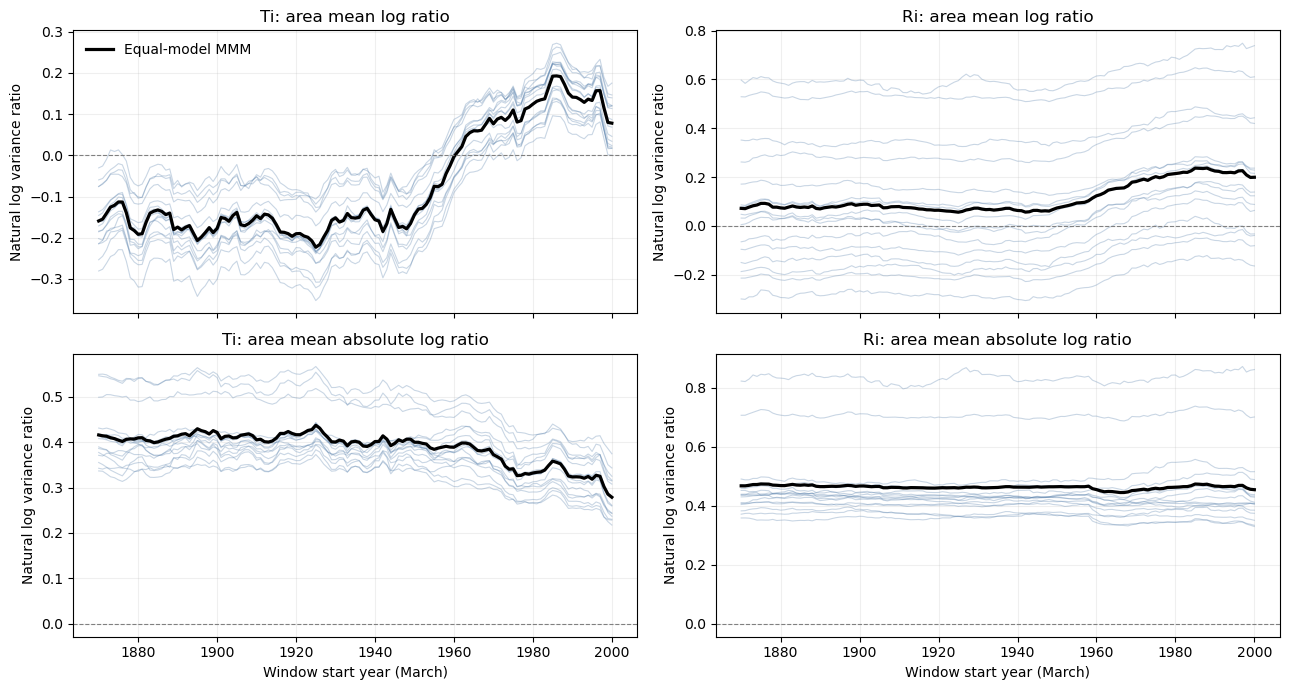

In [12]:
# %% 9. Global variance mismatch series: signed bias and non-cancelling magnitude
# Faint lines are MODEL MEANS; black is their equal-model MMM. The zero reference
# means matched local variances, not a moving observational time series.
fig_sep_logvar, axes_sep_logvar = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
years = sep_plot_archive["coordinates"]["start_year"]
for row, reduction in enumerate(["mean", "abs_mean"]):
    for column, field in enumerate(["Ti", "Ri"]):
        key = f"global_logvar_{field}_{reduction}"
        ax = axes_sep_logvar[row, column]
        ax.plot(years, sep_plot_archive["model_means"][experiment][key].T, color="#4E79A7", alpha=.3, lw=.8)
        ax.plot(years, sep_plot_archive["MMM"][experiment][key], color="black", lw=2.3, label="Equal-model MMM")
        ax.axhline(0, color="0.5", lw=.8, ls="--")
        ax.set_title(f"{field}: area {'mean log ratio' if row == 0 else 'mean absolute log ratio'}")
        ax.set_ylabel("Natural log variance ratio")
        ax.grid(alpha=.2)
        if row == 1:
            ax.set_xlabel("Window start year (March)")
axes_sep_logvar[0, 0].legend(frameon=False)
fig_sep_logvar.tight_layout()
plt.show()
